<a href="https://colab.research.google.com/github/yutaota/intro_to_causal_inference/blob/main/Ex07_DID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

このノートブックでは、Difference-in-Differences（DID）を人工データで確認します。

### 1. データ生成

    処置群のサンプルサイズ:20
    対応する対照群サンプルサイズ:20
    処置前時点数4, 処置後時点数:4
    平均処置効果:-2


### 2. データの書き込みと読み込み
    最終課題の演習の準備として、外部にデータを書き出して、読み込む練習をします。
    
### 3. データの可視化
    各サンプルの計８時点のデータを時系列プロット


### 4. TWFE（Two-Way Fix Effects）

    `Y_it = α + γ G_i + λ_t + τ G_i Post_t + β X_it + ε_it`

    ただし、`λ_t` は複数時点の時点固定効果

### 5. Event Study DID

    `Y_it = α + γ G_i + λ_t + Σ_{k≠-1} τ_k G_i I(t - T* = k) + β X_it + ε_it`


## 1. データ生成

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# シードを設定して再現性を確保
np.random.seed(42)

# ユニット数
n_treated = 20
n_control = 20
n_units = n_treated + n_control

# 処置開始時点
T_star = 0

# 相対時点：pre 4期, post 4期
rel_times = np.array([-4, -3, -2, -1, 0, 1, 2, 3])

# 処置効果の真の値
true_tau = -2.0

# ユニットID
unit_ids = np.arange(n_units)

# G_i：処置群ダミー
G_unit = np.r_[np.ones(n_treated), np.zeros(n_control)]

# γ G_i：処置群と対照群の平均的な水準差
gamma = 1.0

# λ_t：時点固定効果
lambda_t = {-4: -0.6, -3: -0.4, -2: -0.2,-1:
            0.0, 0:  0.3, 1:  0.6, 2:  0.9, 3:  1.2}

# 共変量の係数
beta1 = 0.8
beta2 = -0.6

rows = []

for i in unit_ids:
    for rel_time in rel_times:
        # G_i
        G = G_unit[i]

        # Post_t
        Post = 1 if rel_time >= 0 else 0

        # G_i Post_t
        G_Post = G * Post

        # X_it：時変共変量
        X1 = np.random.normal(0, 1)
        X2 = np.random.normal(0, 1)

        # ε_it
        eps = np.random.normal(0, 0.8)

        # Y_it
        Y = (10 + gamma * G + lambda_t[rel_time] + true_tau * G_Post +
             beta1 * X1 + beta2 * X2 + eps)

        rows.append({"unit_id": i, "rel_time": rel_time, "G": int(G),
            "Post": Post, "G_Post": int(G_Post), "X1": X1, "X2": X2, "Y": Y})

data = pd.DataFrame(rows)

print("データの先頭")
display(data.head())

データの先頭


,unit_id,rel_time,G,Post,G_Post,X1,X2,Y
0,0,-4,1,0,0,0.496714,-0.138264,11.398481
1,0,-3,1,0,0,1.523030,-0.234153,11.771606
2,0,-2,1,0,0,1.579213,0.767435,11.227330
3,0,-1,1,0,0,0.542560,-0.463418,11.339515
4,0,0,1,1,1,0.241962,-1.913280,9.261604


## 2. データの書き込みと読み込み

In [8]:
# 生成したデータをCSVファイルとして保存
data.to_csv("did_sample_data.csv", index=False)

# 保存したCSVファイルを読み込む
data = pd.read_csv("did_sample_data.csv")

## 3. 可視化

処置群 `G = 1` をオレンジ、対照群 `G = 0` を青で表示します。

細い線は各ユニットの時系列、太い線は各時点の平均です。


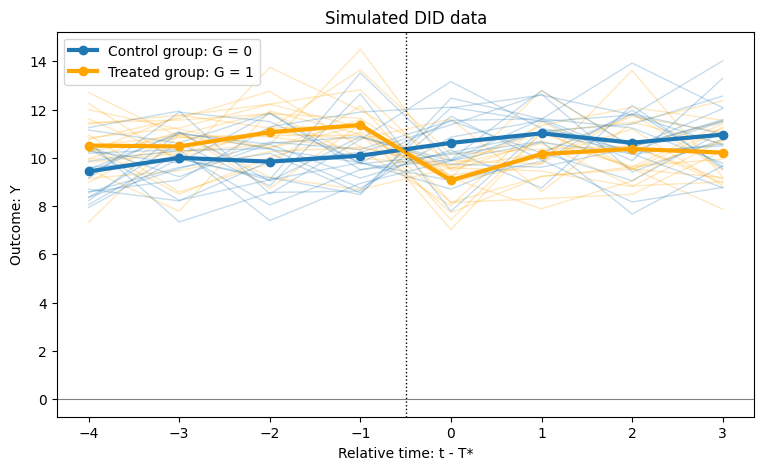

In [9]:
plt.figure(figsize=(9, 5))

# 全サンプルの時系列
for unit_id, df_i in data.groupby("unit_id"):
    if df_i["G"].iloc[0] == 1:
        color = "orange"
    else:
        color = "tab:blue"
    plt.plot(df_i["rel_time"], df_i["Y"], color=color, alpha=0.25, linewidth=1)

# 群ごとの平均
mean_data = data.groupby(["G", "rel_time"])["Y"].mean().reset_index()

for G_value, df_g in mean_data.groupby("G"):
    if G_value == 1:
        label = "Treated group: G = 1"
        color = "orange"
    else:
        label = "Control group: G = 0"
        color = "tab:blue"
    plt.plot(df_g["rel_time"], df_g["Y"], color=color, linewidth=3, marker="o", label=label)

plt.axvline(-0.5, color="black", linestyle=":", linewidth=1)
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("Relative time: t - T*")
plt.ylabel("Outcome: Y")
plt.title("Simulated DID data")
plt.legend()
plt.show()


## 4. TWFE

`Y_it = α + γ G_i + λ_t + τ G_i Post_t + β X_it + ε_it`

Pythonでは次のように対応します。

- `G_i` → `G`
- `λ_t` → `rel_time` から作成した時点ダミー
- `G_i Post_t` → `G_Post`
- `X_it` → `X1`, `X2`
- `τ` → `G_Post` の係数

したがって、説明変数は次のように作ります。

`G_Post, G, rel_timeの時点ダミー, X1, X2`

In [10]:
lambda_dummies = pd.get_dummies(data["rel_time"], prefix="lambda", drop_first=True, dtype=int)

X_twfe = pd.concat(
    [data[["G_Post", "G", "X1", "X2"]], lambda_dummies],
    axis=1
)

X_twfe = sm.add_constant(X_twfe)
y_twfe = data["Y"]

model_twfe = sm.OLS(y_twfe, X_twfe)
twfe_model = model_twfe.fit()

print("TWFEの結果")
print(twfe_model.summary())

print("\n推定された処置効果 tau：", twfe_model.params["G_Post"])
print("真の処置効果 tau：", true_tau)


TWFEの結果
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     50.87
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.11e-62
Time:                        11:57:54   Log-Likelihood:                -384.37
No. Observations:                 320   AIC:                             792.7
Df Residuals:                     308   BIC:                             838.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3507      0.145     64.468 

## 5. Event study

`Y_it = α + γ G_i + λ_t + Σ_{k≠-1} τ_k G_i I(t - T* = k) + β X_it + ε_it`

基準時点は `k = -1` とします。

Pythonでは、各 `k` について

`G_i I(t - T* = k)`

に対応するダミー変数を作ります。

また、`λ_t` に対応するため、`rel_time` から時点ダミーも作ります。

In [11]:
# Event study用のダミーを作る
# 基準時点 k = -1 は落とす
baseline_k = -1
event_terms = []

for k in rel_times:
    if k == baseline_k:
        continue

    if k < 0:
        name = f"G_k_m{abs(k)}"
    else:
        name = f"G_k_{k}"

    # G_i I(t - T* = k)
    data[name] = ((data["G"] == 1) & (data["rel_time"] == k)).astype(int)
    event_terms.append(name)

event_formula = "Y ~ " + " + ".join(event_terms) + " + G + C(rel_time) + X1 + X2"

lambda_dummies = pd.get_dummies(data["rel_time"], prefix="lambda", drop_first=True, dtype=int)

X_event = pd.concat(
    [data[event_terms], data[["G", "X1", "X2"]], lambda_dummies],
    axis=1
)

X_event = sm.add_constant(X_event)
y_event = data["Y"]

model_event = sm.OLS(y_event, X_event)
event_model = model_event.fit()

print("Event studyの回帰結果")
print(event_model.summary())


Event studyの回帰結果
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     32.98
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.14e-58
Time:                        11:57:54   Log-Likelihood:                -382.12
No. Observations:                 320   AIC:                             800.2
Df Residuals:                     302   BIC:                             868.1
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2915      0.184   

## Event studyの図


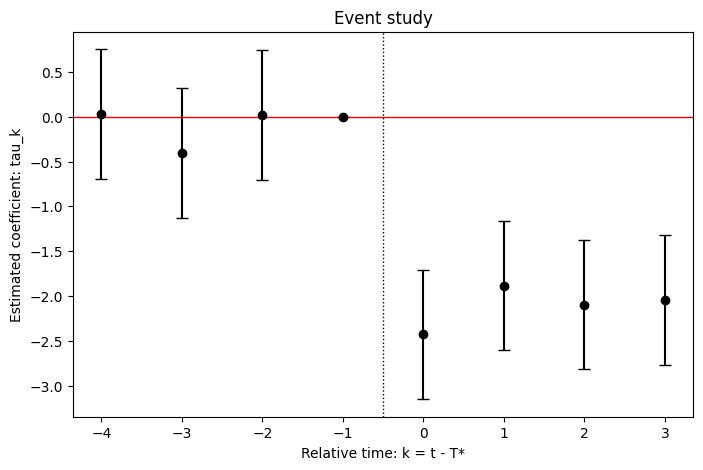

In [12]:
# Event studyの推定値を回帰結果から取り出す
event_rows = []

for k in rel_times:
    if k == baseline_k:
        event_rows.append({
            "k": k,
            "tau_k": 0.0,
            "std err": 0.0
        })
    else:
        if k < 0:
            name = f"G_k_m{abs(k)}"
        else:
            name = f"G_k_{k}"

        event_rows.append({
            "k": k,
            "tau_k": event_model.params[name],
            "std err": event_model.bse[name]
        })

event_result = pd.DataFrame(event_rows)

plt.figure(figsize=(8, 5))

plt.errorbar(
    event_result["k"],
    event_result["tau_k"],
    yerr=1.96 * event_result["std err"],
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

plt.axhline(0, color="red", linewidth=1)
plt.axvline(-0.5, color="black", linestyle=":", linewidth=1)

plt.xlabel("Relative time: k = t - T*")
plt.ylabel("Estimated coefficient: tau_k")
plt.title("Event study")
plt.xticks(rel_times)
plt.show()